In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [28]:
ruta = "fp.csv"
df = pd.read_csv(ruta)

# Eliminar columnas no predictoras (id, Project, YearEnd, Language)
columnas_a_eliminar = ['id', 'Project', 'YearEnd', 'Language']
df.drop(columns=[col for col in columnas_a_eliminar if col in df.columns], inplace=True)



In [29]:
target = 'PointsAjust'
features = [col for col in df.columns if col != target]
print(df.head(100))
print(df.info())

    TeamExp  ManagerExp  Length  Effort  Transactions  Entities  \
0         1           4      12    5152           253        52   
1         0           0       4    5635           197       124   
2         4           4       1     805            40        60   
3         0           0       5    3829           200       119   
4         0           0       4    2149           140        94   
..      ...         ...     ...     ...           ...       ...   
76        4           4      12    1400           229       169   
77        4           3      12    2800           227        73   
78        4           4      24    9520           395       193   
79        4           3      12    5880           469       176   
80        4           4      36   23940           886       241   

    PointsNonAdjust  Adjustment  PointsAjust  
0               305          34          302  
1               321          33          315  
2               100          18           83  
3      

In [38]:
print("Dimensiones antes de eliminar outliers:", df.shape)

# Eliminar outliers (usando IQR) ANTES de dividir (esto es aceptable, pues es limpieza global)
df_clean = df.copy()
for col in features:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df_clean = df_clean[(df_clean[col] >= lower) & (df_clean[col] <= upper)]

print("Dimensiones después de eliminar outliers:", df_clean.shape)


Dimensiones antes de eliminar outliers: (81, 9)
Dimensiones después de eliminar outliers: (63, 9)


In [31]:
# =============================================================================
# 2. DIVIDIR EN ENTRENAMIENTO (70%) Y PRUEBA (30%) ANTES DE ESCALAR
# =============================================================================
X = df_clean[features]
y = df_clean[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print("\nTamaños después de división (sin escalar):")
print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_test:  {X_test.shape},  y_test:  {y_test.shape}")


Tamaños después de división (sin escalar):
X_train: (44, 8), y_train: (44,)
X_test:  (19, 8),  y_test:  (19,)


In [32]:
# =============================================================================
# 3. ESCALAR: ajustar scaler SOLO con entrenamiento, luego transformar ambos
# =============================================================================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convertir a DataFrame para mantener nombres de columnas
X_train_scaled = pd.DataFrame(X_train_scaled, columns=features, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=features, index=X_test.index)


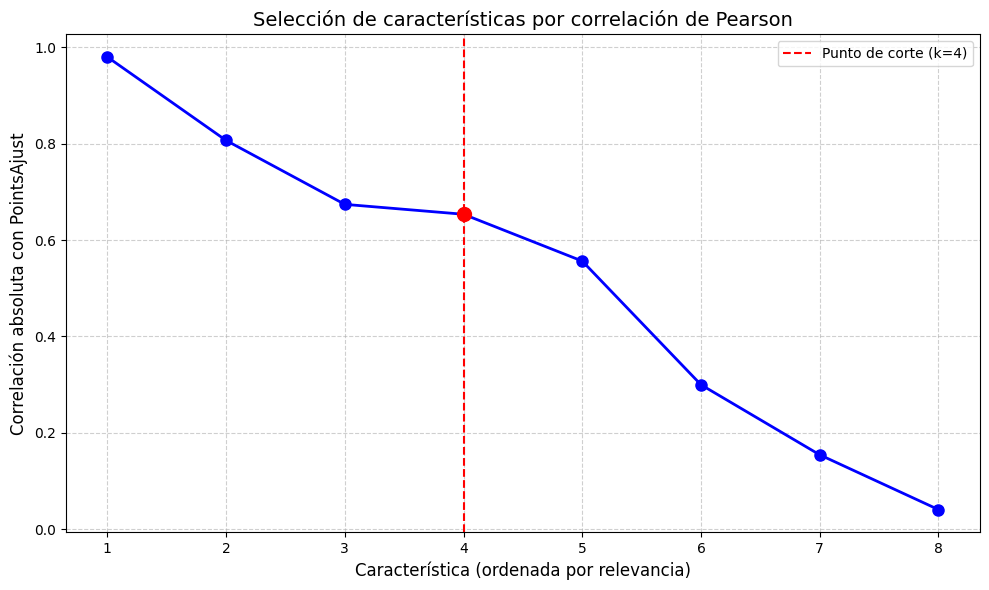


--- Punto de corte por máxima caída: 4 características ---
Características seleccionadas: ['PointsNonAdjust', 'Transactions', 'Effort', 'Adjustment']
Correlaciones en entrenamiento:
PointsNonAdjust    0.9798
Transactions       0.8067
Effort             0.6740
Adjustment         0.6535
Name: PointsAjust, dtype: float64


In [33]:

# =============================================================================
# 4. SELECCIÓN DE CARACTERÍSTICAS CON GRÁFICA Y PUNTO DE CORTE
# =============================================================================
# Calcular correlación con el objetivo solo en entrenamiento escalado
corr_train = X_train_scaled.copy()
corr_train[target] = y_train.values
corr_matrix_train = corr_train.corr()
corr_target = corr_matrix_train[target].abs().sort_values(ascending=False)

# Excluir la propia variable objetivo (PointsAjust)
corr_target = corr_target.drop(target)

# --- Gráfica de correlaciones y método del codo ---
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(corr_target)+1), corr_target.values, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Característica (ordenada por relevancia)', fontsize=12)
plt.ylabel('Correlación absoluta con PointsAjust', fontsize=12)
plt.title('Selección de características por correlación de Pearson', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)

# Calcular diferencias entre correlaciones consecutivas
diferencias = np.diff(corr_target.values)
max_diferencia_idx = np.argmax(diferencias)   # índice de la mayor caída
punto_corte = max_diferencia_idx + 2         # número de características a seleccionar

# Resaltar el punto de corte
plt.axvline(x=punto_corte, color='red', linestyle='--', label=f'Punto de corte (k={punto_corte})')
plt.plot(punto_corte, corr_target.values[punto_corte-1], 'ro', markersize=10)
plt.legend()
plt.tight_layout()
plt.show()

# Seleccionar las características hasta el punto de corte
top_features = corr_target.index[:punto_corte].tolist()
print(f"\n--- Punto de corte por máxima caída: {punto_corte} características ---")
print("Características seleccionadas:", top_features)
print("Correlaciones en entrenamiento:")
print(corr_target[top_features].round(4))




In [34]:
# =============================================================================
# 5. CREAR LOS DOS CONJUNTOS FINALES (original y reducido)
# =============================================================================
# Conjunto original: todas las características escaladas
X_train_orig = X_train_scaled
X_test_orig = X_test_scaled

# Conjunto reducido: solo las top_features
X_train_red = X_train_scaled[top_features]
X_test_red = X_test_scaled[top_features]

print("\n--- Conjunto original (todas) ---")
print(f"Entrenamiento: {X_train_orig.shape}, Prueba: {X_test_orig.shape}")
print("--- Conjunto reducido (top 5) ---")
print(f"Entrenamiento: {X_train_red.shape}, Prueba: {X_test_red.shape}")



--- Conjunto original (todas) ---
Entrenamiento: (44, 8), Prueba: (19, 8)
--- Conjunto reducido (top 5) ---
Entrenamiento: (44, 4), Prueba: (19, 4)



RESUMEN DE RESULTADOS (MSE, MAE, R2)
                                  MSE      MAE      R2
Árbol (todas)               1656.6842  25.2105  0.8780
Árbol (mejores)              744.0000  19.8947  0.9452
Random Forest (todas)       1001.5527  17.0974  0.9263
Random Forest (mejores)      945.9112  17.5463  0.9304
Regresión Lineal (todas)     207.2397   8.5798  0.9847
Regresión Lineal (mejores)   216.3944   8.7086  0.9841


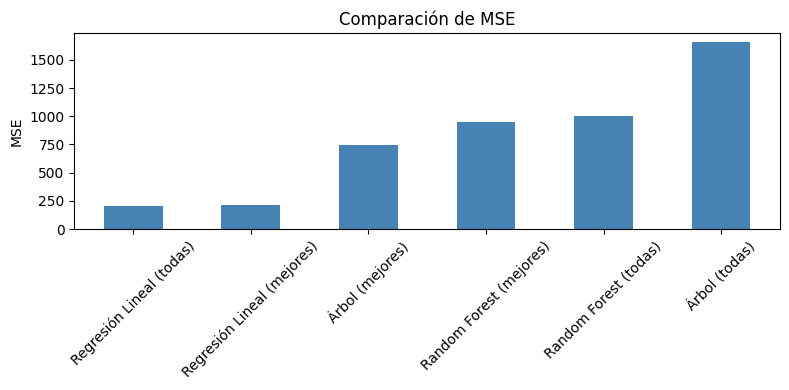

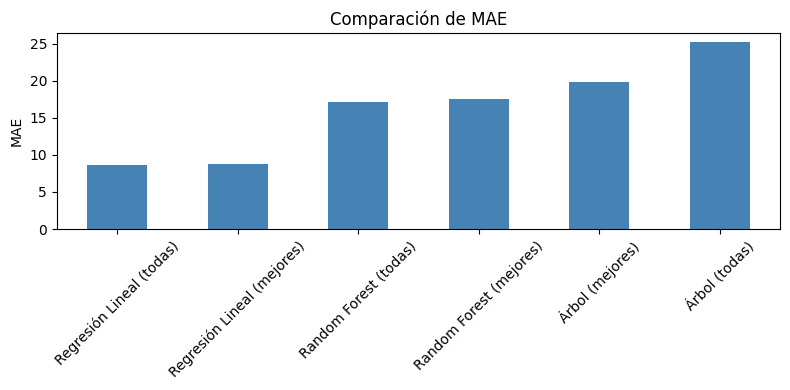

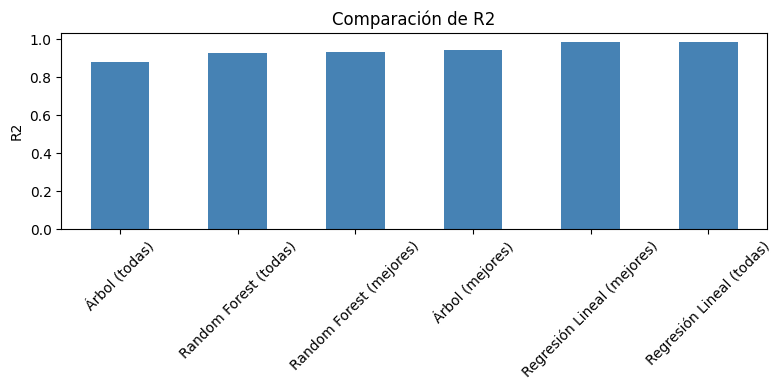

In [35]:
# =============================================================================
# 6. ENTRENAMIENTO Y EVALUACIÓN DE MODELOS
# =============================================================================
resultados = {}

# Árbol de regresión
dt_all = DecisionTreeRegressor(random_state=42)
dt_all.fit(X_train_orig, y_train)
y_pred = dt_all.predict(X_test_orig)
resultados['Árbol (todas)'] = {
    'MSE': mean_squared_error(y_test, y_pred),
    'MAE': mean_absolute_error(y_test, y_pred),
    'R2': r2_score(y_test, y_pred)
}

dt_red = DecisionTreeRegressor(random_state=42)
dt_red.fit(X_train_red, y_train)
y_pred_red = dt_red.predict(X_test_red)
resultados['Árbol (mejores)'] = {
    'MSE': mean_squared_error(y_test, y_pred_red),
    'MAE': mean_absolute_error(y_test, y_pred_red),
    'R2': r2_score(y_test, y_pred_red)
}

# Bosque aleatorio
rf_all = RandomForestRegressor(random_state=42)
rf_all.fit(X_train_orig, y_train)
y_pred = rf_all.predict(X_test_orig)
resultados['Random Forest (todas)'] = {
    'MSE': mean_squared_error(y_test, y_pred),
    'MAE': mean_absolute_error(y_test, y_pred),
    'R2': r2_score(y_test, y_pred)
}

rf_red = RandomForestRegressor(random_state=42)
rf_red.fit(X_train_red, y_train)
y_pred_red = rf_red.predict(X_test_red)
resultados['Random Forest (mejores)'] = {
    'MSE': mean_squared_error(y_test, y_pred_red),
    'MAE': mean_absolute_error(y_test, y_pred_red),
    'R2': r2_score(y_test, y_pred_red)
}

# Regresión lineal
lr_all = LinearRegression()
lr_all.fit(X_train_orig, y_train)
y_pred = lr_all.predict(X_test_orig)
resultados['Regresión Lineal (todas)'] = {
    'MSE': mean_squared_error(y_test, y_pred),
    'MAE': mean_absolute_error(y_test, y_pred),
    'R2': r2_score(y_test, y_pred)
}

lr_red = LinearRegression()
lr_red.fit(X_train_red, y_train)
y_pred_red = lr_red.predict(X_test_red)
resultados['Regresión Lineal (mejores)'] = {
    'MSE': mean_squared_error(y_test, y_pred_red),
    'MAE': mean_absolute_error(y_test, y_pred_red),
    'R2': r2_score(y_test, y_pred_red)
}

# =============================================================================
# 7. RESULTADOS
# =============================================================================
df_resultados = pd.DataFrame(resultados).T
print("\n" + "="*70)
print("RESUMEN DE RESULTADOS (MSE, MAE, R2)")
print("="*70)
print(df_resultados.round(4))

# Gráficos opcionales
for met in ['MSE', 'MAE', 'R2']:
    plt.figure(figsize=(8,4))
    df_resultados[met].sort_values().plot(kind='bar', color='steelblue')
    plt.title(f'Comparación de {met}')
    plt.ylabel(met)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()